### Bayesian Regression

In [33]:
# pip install pymc arviz

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az

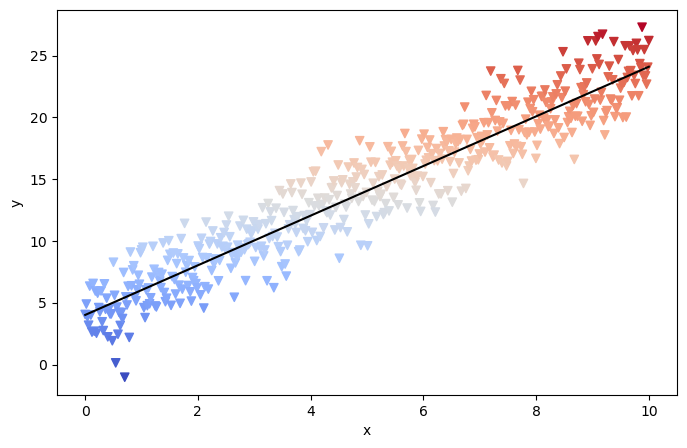

In [ ]:
# Create some random data to fit 
inter = 4
slope = 2

x = np.linspace(0, 10, 500)
y = inter + slope * x + np.random.normal(loc=0, scale=2, size=len(x))

# Simple linear regression
reg = np.polyfit(x, y, deg=1)
inter = reg[1]
slope = reg[0]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm')
ax.plot(x, inter + slope * x, color='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

We obtain as results the slope and the intecept of the regression line via OLS

In [36]:
# Bayesian model for regression

with pm.Model() as model:
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Linear model
    mu = alpha + beta * x

    # Likelihood
    y_obs = pm.Normal("y", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [38]:
az.summary(
    trace,
    var_names=["alpha", "beta", "sigma"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,4.012,0.173,3.7,4.3,1664,1891,1.00,0.0042,0.0031
beta,2.008,0.03,2,2.1,1619,1842,1.00,0.00075,0.00054
sigma,1.934,0.061,1.8,2,2125,1998,1.00,0.0013,0.00097


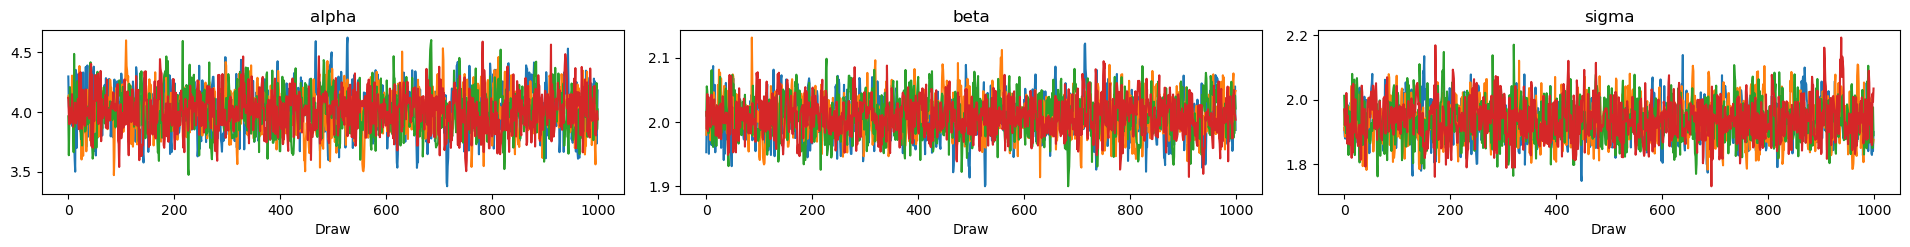

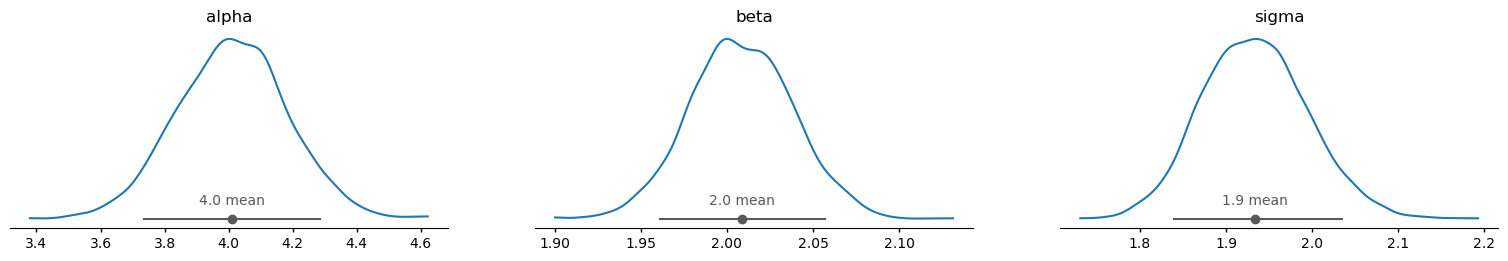

In [55]:
az.plot_trace(
    trace,
    var_names=["alpha", "beta", "sigma"]
)

plt.tight_layout()
plt.show()


import arviz_plots as azp

azp.plot_dist(
    trace,
    var_names=["alpha", "beta", "sigma"],
    group="posterior"
)
plt.show()

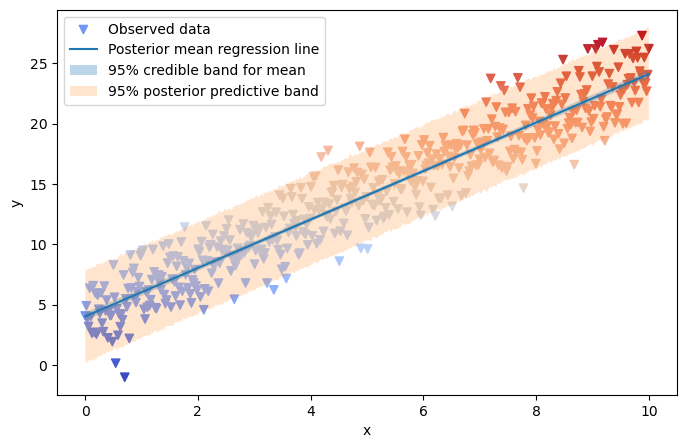

In [ ]:
posterior_samples = trace["posterior"].to_dataset().stack(sample=("chain", "draw"))
alpha_samples = posterior_samples["alpha"].values
beta_samples = posterior_samples["beta"].values
sigma_samples = posterior_samples["sigma"].values

# Shape: (n_samples, n_x_points)
mu_lines = alpha_samples[:, None] + beta_samples[:, None] * x[None, :]

# Mean regression line
mu_mean = mu_lines.mean(axis=0)

# 95% interval for the mean regression line
# Important: axis=0 means across posterior samples
mu_hdi = np.quantile(mu_lines, [0.025, 0.975], axis=0).T

rng = np.random.default_rng(42)

# Add observation noise sigma
y_pred_lines = rng.normal(
    loc=mu_lines,
    scale=sigma_samples[:, None]
)

# 95% posterior predictive interval
y_pred_hdi = np.quantile(y_pred_lines, [0.025, 0.975], axis=0).T




fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm', label="Observed data")
ax.plot(x, mu_mean, label="Posterior mean regression line")
ax.fill_between(
    x,
    mu_hdi[:, 0],
    mu_hdi[:, 1],
    alpha=0.3,
    label="95% credible band for mean"
)
ax.fill_between(
    x,
    y_pred_hdi[:, 0],
    y_pred_hdi[:, 1],
    alpha=0.2,
    label="95% posterior predictive band"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.legend()
plt.show()

### Real Data Bayesian Regression